### Importación de librerías esenciales y el dataset a utilizar

Para este caso se utilizaron diferentes algoritmos de Machine Learning de los cuales dos de ellos están incluidos dentro del _aprendizaje supervisado_ y otro contenido dentro del _aprendizaje no supervisado_. Así, tenemos tres grandes métodos de Machine Learning donde tomaremos cinco algoritmos, estos tres grandes métodos son las **regresiones**, las **clasificaciones** y el agrupamiento mediante **clusters**.

Para el desarrollo de este trabajo se harán las distinciones de qué estaremos utilizando todo el tiempo y en el contexto en el que nos encontramos, sin embargo, hay librerías básicas que usaremos independientemente de lo que estemos trabajando, estas son:
 - `pandas`: librería para manipulación y análisis de datos tabulares con DataFrames.
 - `numpy`: librería fundamental para computación numérica con arreglos eficientes y funciones matemáticas.
 - `matplotlib.pyplot`: herramienta de visualización para crear gráficos estáticos e interactivos.

Continuando con el manejo de los datos, pero ahora más destinados a Machine Learning, se tienen las siguientes librerías:
 - `StandarScaler`: clase de scikit-learn que estandariza características al eliminar la media y escalar a la varianza unitaria, mejorando el desempeño de modelos sensibles a escalas.
 - `train_test_split`: función de scikit-learn para dividir un conjunto de datos en conjuntos de entrenamiento y prueba, facilitando la evaluación del rendimiento del modelo.

In [1]:
# Librerías básicas de manejo de datos en Python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # Manejo especial de gráficas

# Librerías especializadas para Machine Learning en Python con sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Importa la biblioteca de advertencias
import warnings

# Filtra las advertencias para que se ignoren durante la ejecución
warnings.filterwarnings('ignore')

Seguimos con la importación de los datos<sup>[1]</sup> a utilizar y un manejo de los mismos, para ello comenzamos con la implementación de funciones de las librerías previamente importadas.

Se utiliza la función `.drop()` para eliminar todas aquellas columnas que no se van a utilizar o sencillamente no son de interés.

In [2]:
df = pd.read_excel("Basededatos2.xlsx").drop(["k1","k2","k3","t2"], axis=1)
df # Previsualización del dataset

,t,t1_x1,t1_x2,t2_x1,t2_x2,t3_x1,t3_x2,t4_x1,t4_x2,t5_x1,t5_x2,t6_x1,t6_x2,t7_x1,t7_x2
0,0.000000,-0.194338,0.179767,-0.199750,0.140901,-0.218747,0.217457,0.382,0.880,0.446,0.920,-0.115640,0.129146,-0.240359,0.037728
1,0.016667,-0.191922,0.177438,-0.199775,0.140901,-0.218772,0.217490,0.382,0.880,0.446,0.920,-0.115657,0.129108,-0.240365,0.037744
2,0.033334,-0.191929,0.177424,-0.199774,0.140901,-0.213463,0.214950,0.386,0.880,0.440,0.927,-0.126428,0.123593,-0.244831,0.033406
3,0.050001,-0.188284,0.173918,-0.202337,0.137434,-0.213563,0.214983,0.386,0.880,0.440,0.927,-0.126356,0.123346,-0.244893,0.033309
4,0.066668,-0.188301,0.173866,-0.202301,0.137439,-0.205699,0.210267,0.391,0.883,0.435,0.934,-0.136891,0.118264,-0.248041,0.030470
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
596,9.933532,-0.120703,0.112611,-0.193856,0.142760,-0.134690,0.115853,0.438,0.833,0.463,0.912,-0.107481,0.224386,-0.221313,0.078049
597,9.950199,-0.122907,0.114496,-0.193863,0.142966,-0.126459,0.110567,0.438,0.833,0.468,0.907,-0.107419,0.214723,-0.227353,0.071883
598,9.966866,-0.122968,0.114527,-0.196274,0.141813,-0.126484,0.110703,0.437,0.831,0.468,0.907,-0.114128,0.214696,-0.227350,0.071912
599,9.983533,-0.125824,0.117211,-0.196275,0.141898,-0.119315,0.106373,0.437,0.831,0.472,0.903,-0.114280,0.204762,-0.232583,0.066028


El dataset mostrado tiene un total de 15 columnas y 601 filas, en donde hay pares de columnas identificados por `t[i]_x[j]`, `[i]` representa la cantidad de pares siendo un total de siete pares que representan diferentes posiciones iniciales para las masas y con ello, una variación en los modos de oscilación; `[j]` representa la masa a la cual se está refiriendo siendo un total de dos masas. Finalmente, la primera columna llamada `t` representa el tiempo transcurrido, siendo el mismo para todas las trayectorias tomadas del aplicativo _tracker_. 

Tras haber importado el dataset, se hará una visualización gráfica de los datos para conocer a lo que nos estamos enfrentando.

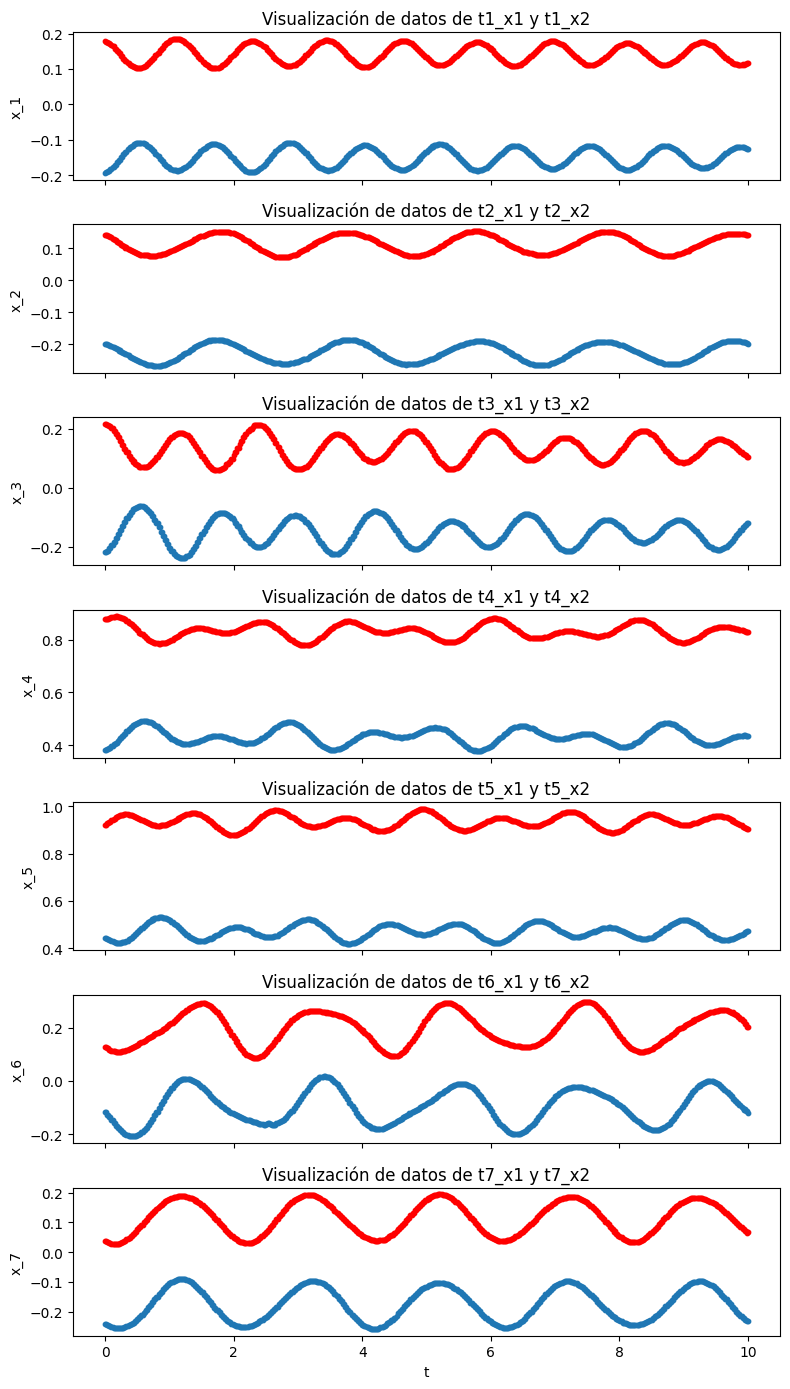

In [3]:
# Lista de columnas ti_x1 y ti_x2
columnas_t_x1 = [f't{i}_x1' for i in range(1, 8)]

# Crear un subplot con 7 gráficas
fig, axs = plt.subplots(7, 1, figsize=(8, 14), sharex=True)

# Iterar sobre las columnas ti_x1
for i, columna_t_x1 in enumerate(columnas_t_x1):
    # Obtener el nombre de la columna ti_x2
    columna_t_x2 = columna_t_x1.replace('_x1', '_x2')
    
    # Graficar las posiciones de la masa 1 (ti_x1) y de la masa 2 (ti_x2)
    axs[i].scatter(df['t'], df[columna_t_x1], label=columna_t_x1, s=10)
    axs[i].scatter(df['t'], df[columna_t_x2], label=columna_t_x2, color='red', s=10)
    
    # Configurar título y etiqueta del eje 'y' para cada gráfica
    axs[i].set_title(f'Visualización de datos de {columna_t_x1} y {columna_t_x2}')
    axs[i].set_ylabel(f'x_{i+1}')

# Configuración final del eje 'x'
plt.xlabel('t')

# Ajustar el diseño para evitar superposiciones
plt.tight_layout()

# Mostrar las gráficas
plt.show()

Finalmente, en pro de seguir analizando los datos y ahora queriendo ver la correlación de los mismos, con ayuda de una librería especial para visualización de gráficos llamada `seaborn`, generamos una matriz de correlación de los datos.

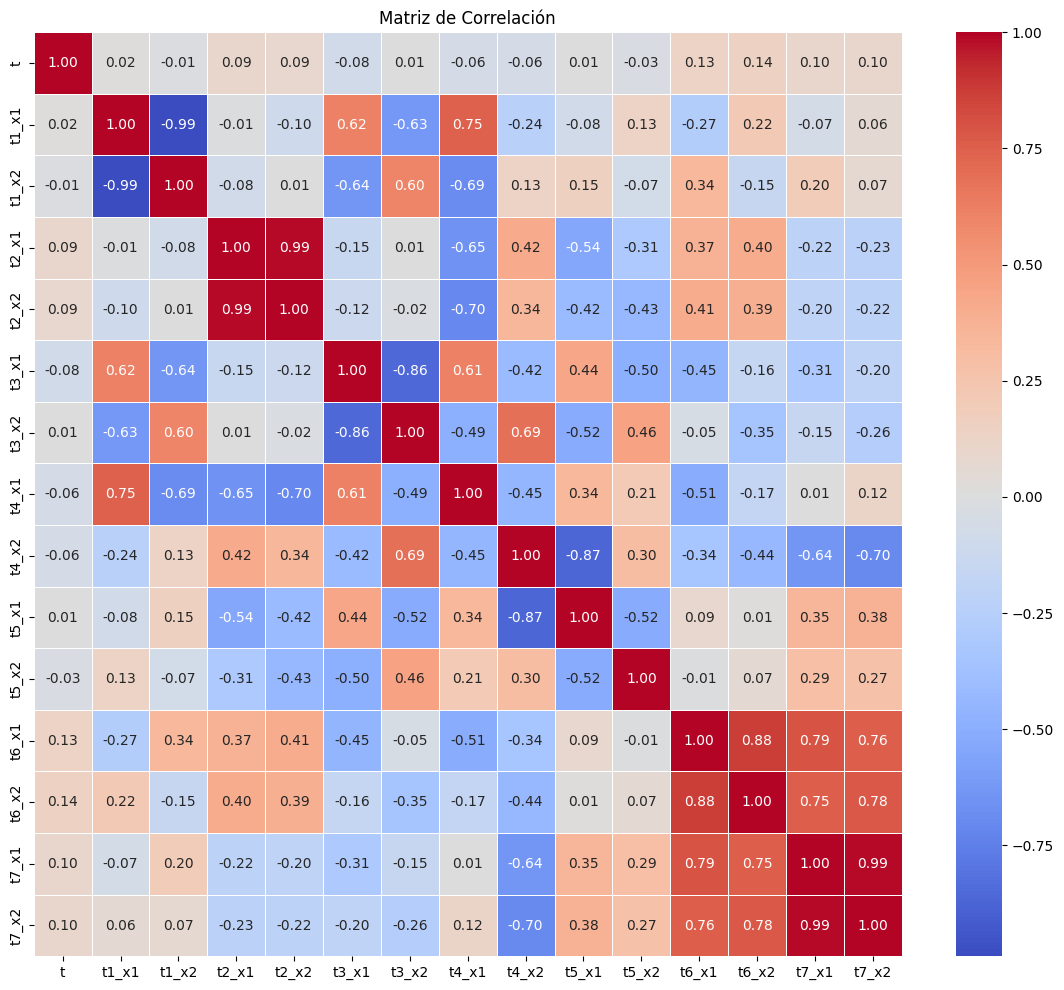

In [4]:
# Establece el tamaño de la figura para la visualización del mapa de calor
plt.figure(figsize=(14, 12))

# Crea un mapa de calor (heatmap) de la matriz de correlación del DataFrame
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

# Establece el título del gráfico
plt.title('Matriz de Correlación')

# Muestra el gráfico
plt.show()

Luego de haber visto los datos de varias maneras, procedemos ahora sí con la implementación del código para Machine Learning.

### Apliquemos regresiones

Comenzando ya con el código utilizado para realizar Machine Learning, las siguientes librerías fueron necesarias en el uso de regresiones de los cuales se usaron los siguientes algoritmos:
 - `LinearRegression`: modelo de regresión lineal que encuentra la mejor línea de ajuste para predecir valores continuos.
 - `Lasso`: variante de regresión lineal con regularización L1 (Lasso Regression), que permite la selección automática de características importantes y la simplificación del modelo.
 - `Ridge`: variante de regresión lineal con regularización L2 (Ridge Regression), útil para controlar la complejidad del modelo y evitar el sobreajuste.
 - `SVR`: máquina de soporte vectorial para regresión, un modelo que encuentra la mejor función para prever valores continuos.
 - `DecisionTreeRegressor`: un modelo de regresión basado en árboles de decisión, útil para capturar relaciones no lineales en los datos.

Junto a algunas métricas para la evaluación de los modelos, estas son:
 - `mean_absolute_error`: mide la magnitud promedio de los errores absolutos entre valores reales y predicciones, proporcionando una indicación de la precisión del modelo.
 - `mean_squared_error`: calcula la media de los errores cuadrados entre valores reales y predicciones, ofreciendo una medida de la dispersión de los errores.
 - `r2_score`: proporciona la proporción de varianza explicada por el modelo, indicando cuánto se ajustan las predicciones a los datos reales. Un valor más cercano a 1 indica un mejor ajuste.

In [5]:
# Algoritmos
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

# Métricas
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Como una buena práctica, se realizará una estandarización de los datos usando la clase `StandardScaler` de scikit-learn, esta se hará sobre todo el dataset.

In [6]:
# Inicializar el scaler
scaler = StandardScaler()

# Estandarizar todo el DataFrame
df_reg = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

Ahora, se crea una función general llamada `regression` la cual al darle una función de regresión por aplicar, genera siete diferentes gráficas donde el objetivo es que con base en el movimiento de una masa, se pueda llegar a predecir la trayectoria o movimiento de la otra masa. Esta situación planteada deberá salir en principio con buenas métricas debido a que existe una correlación de los datos y esa correlación es conocida tanto en la teoría como en la práctica (experimento).

In [7]:
def regression(algoritmo):
    # Lista de columnas ti_x1 y ti_x2
    columnas_t_x = [f't{i}_x1' for i in range(1, 8)]

    # Crear un subplot con 7 gráficas
    fig, axs = plt.subplots(7, 1, figsize=(8, 14), sharex=True)

    # Crear un DataFrame vacío para almacenar los errores
    errores_df = pd.DataFrame()

    # Crear una lista para almacenar los errores
    errores_lista = []

    for i, columna_t_x in enumerate(columnas_t_x):
        # Dividir los datos en conjuntos de entrenamiento y prueba
        X_train, X_test, y_train, y_test = train_test_split(
            df_reg[['t', columna_t_x]],
            df_reg[columna_t_x.replace('_x1', '_x2')],
            test_size=0.2,
            random_state=42)

        # Crear el modelo y entrenarlo
        model = algoritmo
        model.fit(X_train, y_train)

        # Hacer predicciones en el conjunto de prueba
        y_pred = model.predict(X_test)

        # Agregar los errores a la lista
        errores_lista.append({
            'MAE': mean_absolute_error(y_test, y_pred),
            'MSE': mean_squared_error(y_test, y_pred),
            'RMSE': mean_squared_error(y_test, y_pred, squared=False),
            'R^2': r2_score(y_test, y_pred)})
        
        # Visualizar las predicciones
        axs[i].scatter(X_test['t'],
                       y_test,
                       label='Datos reales',
                       s=10)
        
        axs[i].scatter(X_test['t'],
                       y_pred,
                       label='Predicciones',
                       color='red',
                       s=10)
        
        axs[i].plot(X_test.iloc[X_test['t'].argsort()]['t'],
                    y_pred[X_test['t'].argsort()],
                    color='green',
                    linewidth=1,
                    linestyle='dashed',
                    label='Línea de predicción')
        
        axs[i].set_title(f'{algoritmo.__class__.__name__} para predecir {columna_t_x.replace("_x1", "_x2")}')
        
        axs[i].set_ylabel(columna_t_x.replace('_x1', '_x2'))
    
    # Convertir la lista en un DataFrame
    errores_df = pd.DataFrame(errores_lista, index=columnas_t_x, columns=['MAE', 'MSE', 'RMSE', 'R^2'])

    # Imprimir el DataFrame creado traspuesto
    print(errores_df.T.rename(columns=lambda x: x.replace('_x1', '_x2')))

    # Ajustes finales
    plt.xlabel('t')
    plt.tight_layout()
    plt.show()

Luego de haber creado la función que nos ayudará a obtener las métricas y las gráficas de los datos predichos de la regresión, se comienza a implementar para los diferentes algoritmos de regresión que ya fueron mencionados previamente. Cabe destacar pero manejar la mayor imparcialidad posible y tener un buen análisis de los resultados, todos los parámetros se dejaron por defecto.

#### ``LinearRegression()``

         t1_x2     t2_x2     t3_x2     t4_x2     t5_x2     t6_x2     t7_x2
MAE   0.138838  0.131579  0.449161  0.734775  0.715939  0.424306  0.129894
MSE   0.023785  0.023316  0.262715  0.799830  0.691346  0.234630  0.020952
RMSE  0.154223  0.152697  0.512557  0.894332  0.831472  0.484386  0.144748
R^2   0.977210  0.973318  0.748809  0.197038  0.229169  0.754520  0.980707


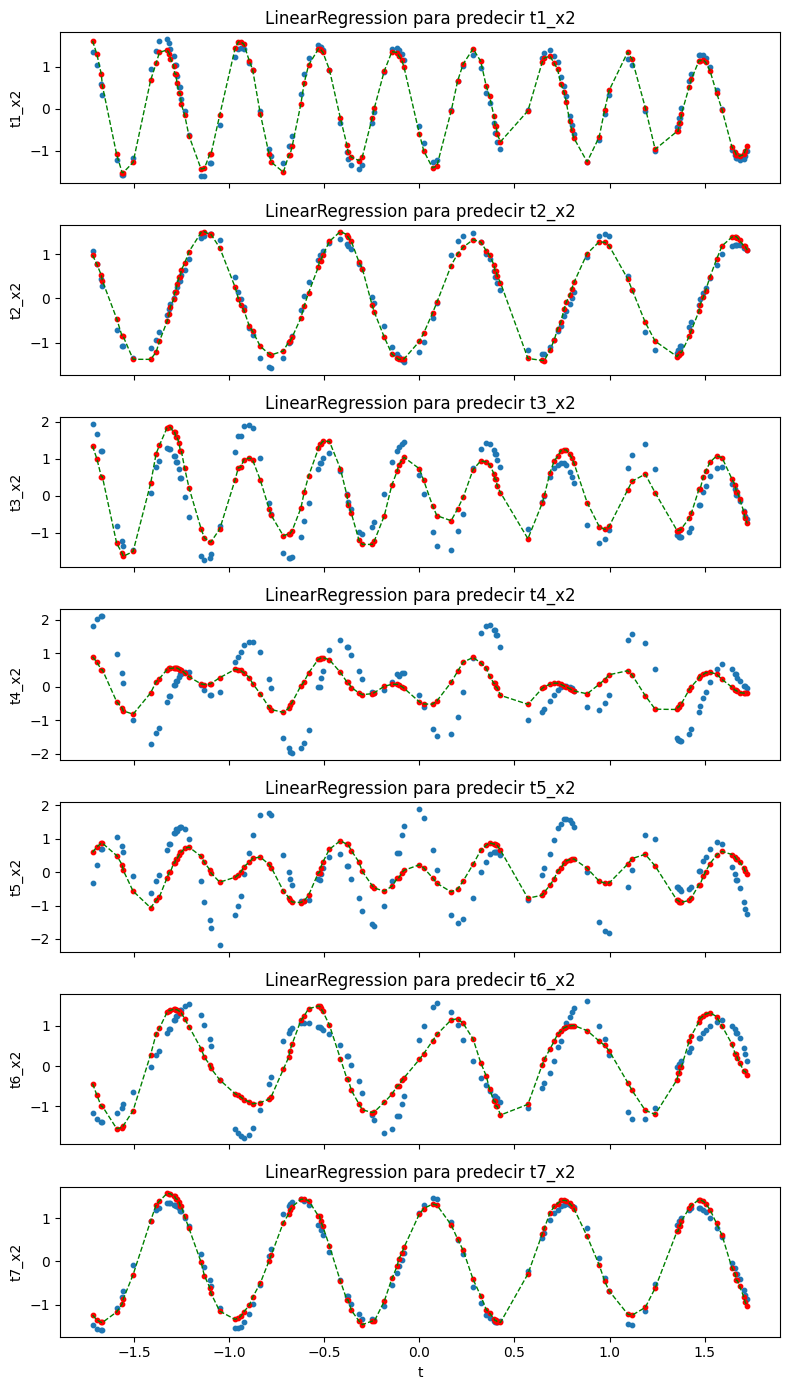

In [8]:
regression(LinearRegression())

El modelo de regresión lineal presenta buen rendimiento en general, pero varía en su capacidad predictiva para diferentes columnas. Mientras que la mayoría de las métricas (MAE, MSE, RMSE) son aceptables, el coeficiente de determinación (R^2) sugiere que el modelo tiene dificultades para explicar la variabilidad en algunas variables (t4_x2 y t5_x2).

#### ``Lasso()``

         t1_x2     t2_x2     t3_x2     t4_x2     t5_x2     t6_x2     t7_x2
MAE   0.925366  0.812332  0.917083  0.776790  0.795950  0.889527  0.958088
MSE   1.074808  0.862451  1.079715  1.001028  0.921321  0.988240  1.110077
RMSE  1.036730  0.928683  1.039093  1.000514  0.959855  0.994103  1.053602
R^2  -0.029868  0.013059 -0.032353 -0.004948 -0.027247 -0.033938 -0.022200


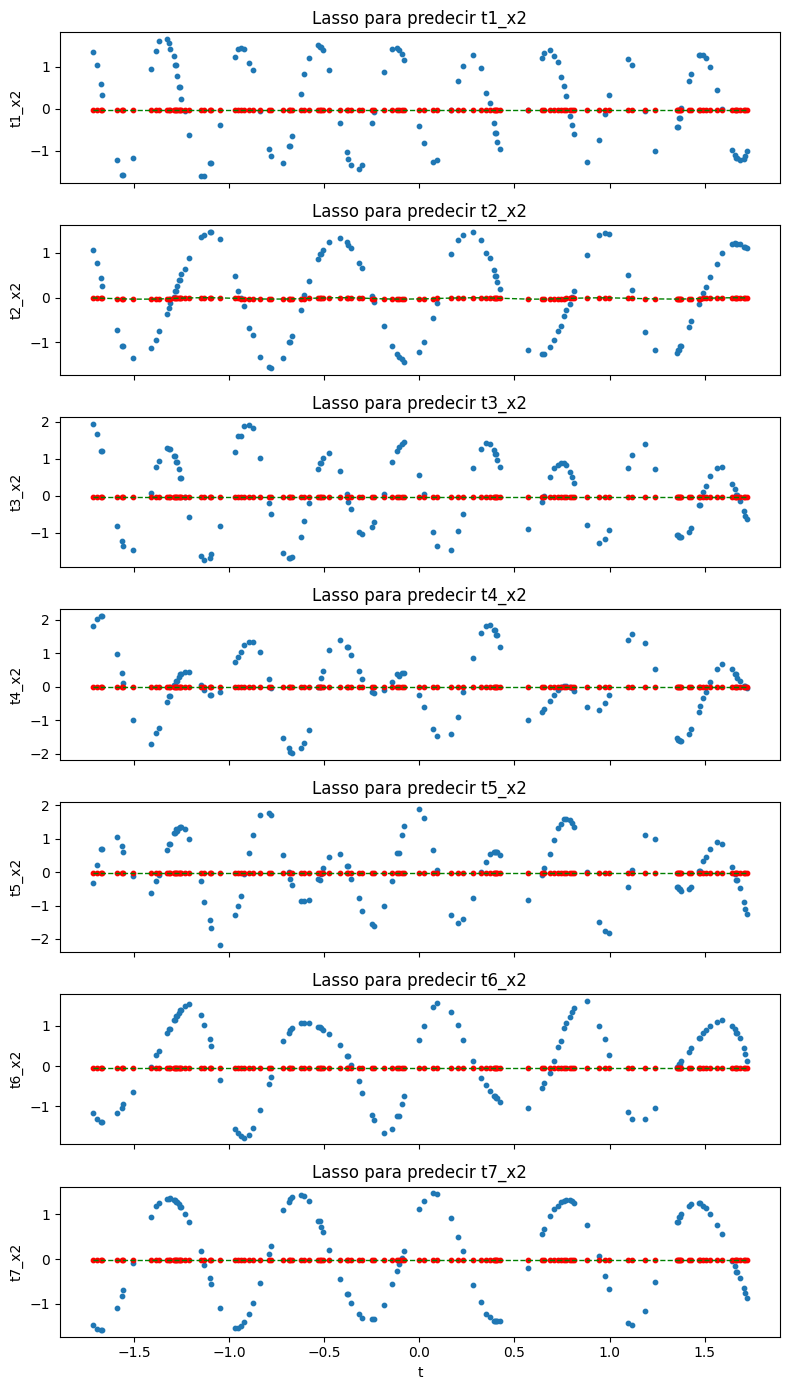

In [9]:
regression(Lasso())

El modelo Lasso exhibe desempeño inferior, con MAE y RMSE más altos y coeficientes de determinación (R^2) cercanos a cero, indicando una capacidad limitada para explicar la variabilidad en las variables de salida (t1_x2 a t7_x2).

#### ``Ridge()``

         t1_x2     t2_x2     t3_x2     t4_x2     t5_x2     t6_x2     t7_x2
MAE   0.139279  0.131214  0.448761  0.734718  0.715640  0.423885  0.129316
MSE   0.023919  0.023221  0.262512  0.799873  0.691241  0.234461  0.020806
RMSE  0.154659  0.152385  0.512359  0.894356  0.831409  0.484212  0.144244
R^2   0.977081  0.973427  0.749003  0.196995  0.229285  0.754697  0.980841


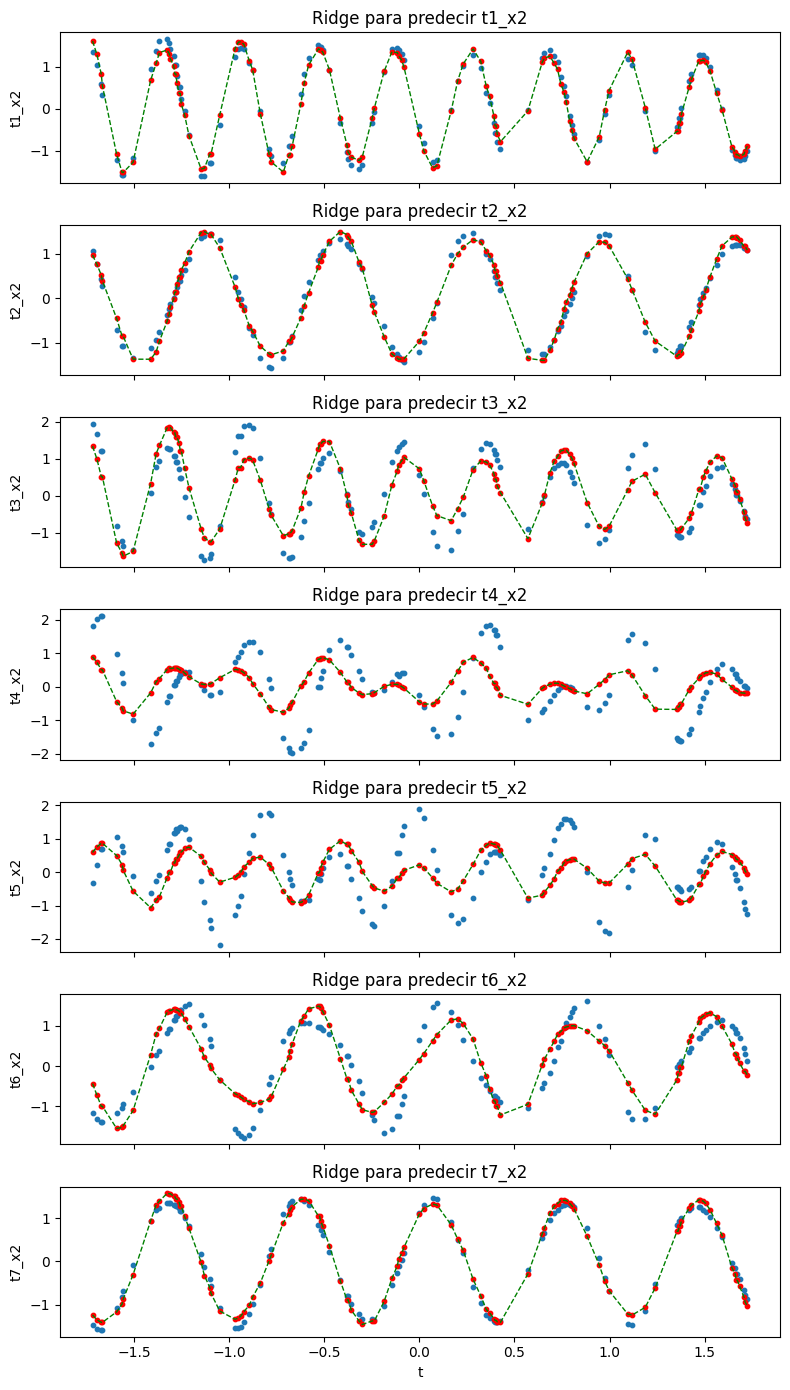

In [10]:
regression(Ridge())

El modelo Ridge presenta un rendimiento similar al de la Regresión Lineal, con MAE y RMSE bajos y coeficientes de determinación (R^2) cercanos a 1, indicando una buena capacidad para explicar la variabilidad en las variables de salida (t1_x2 a t7_x2).

#### ``SVR()``

         t1_x2     t2_x2     t3_x2     t4_x2     t5_x2     t6_x2     t7_x2
MAE   0.124322  0.101355  0.357951  0.720620  0.620278  0.305210  0.083089
MSE   0.019342  0.015115  0.215179  0.804894  0.591928  0.139456  0.010002
RMSE  0.139076  0.122943  0.463874  0.897159  0.769369  0.373438  0.100012
R^2   0.981467  0.982703  0.794260  0.191954  0.340016  0.854096  0.990789


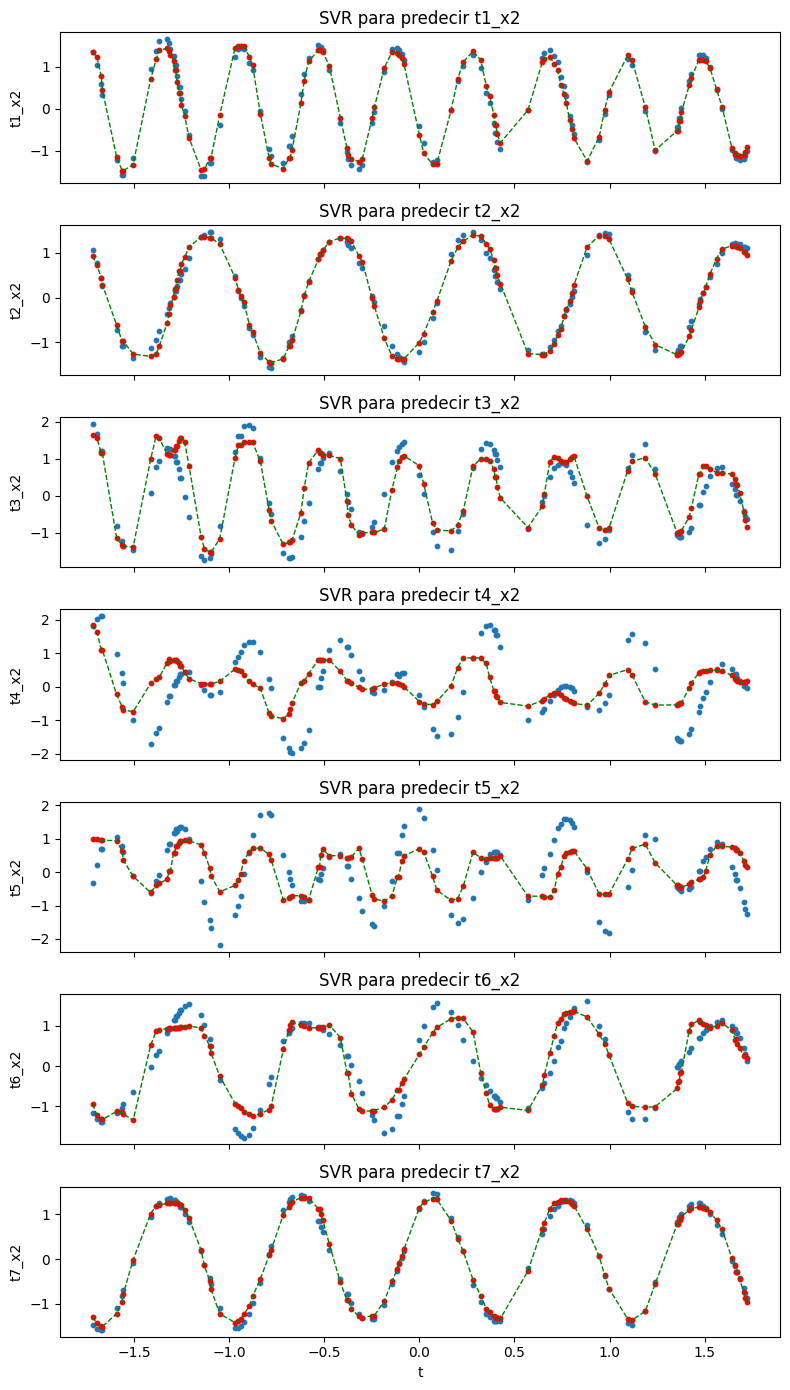

In [11]:
regression(SVR())

El modelo Support Vector Regression (SVR) muestra un rendimiento destacado, con bajos errores (MAE, MSE, RMSE) y coeficientes de determinación (R^2) cercanos a 1 para todas las variables de salida (t1_x2 a t7_x2). Esto indica una capacidad sólida para capturar la relación no lineal entre las variables de entrada (t y t_i_x1) y las variables de salida.

#### ``DecisionTreeRegressor()``

         t1_x2     t2_x2     t3_x2     t4_x2     t5_x2     t6_x2     t7_x2
MAE   0.039736  0.055730  0.103640  0.054208  0.128763  0.053372  0.019281
MSE   0.010858  0.013461  0.084943  0.009019  0.184061  0.013106  0.002520
RMSE  0.104202  0.116019  0.291450  0.094969  0.429023  0.114481  0.050204
R^2   0.989596  0.984597  0.918783  0.990945  0.794777  0.986288  0.997679


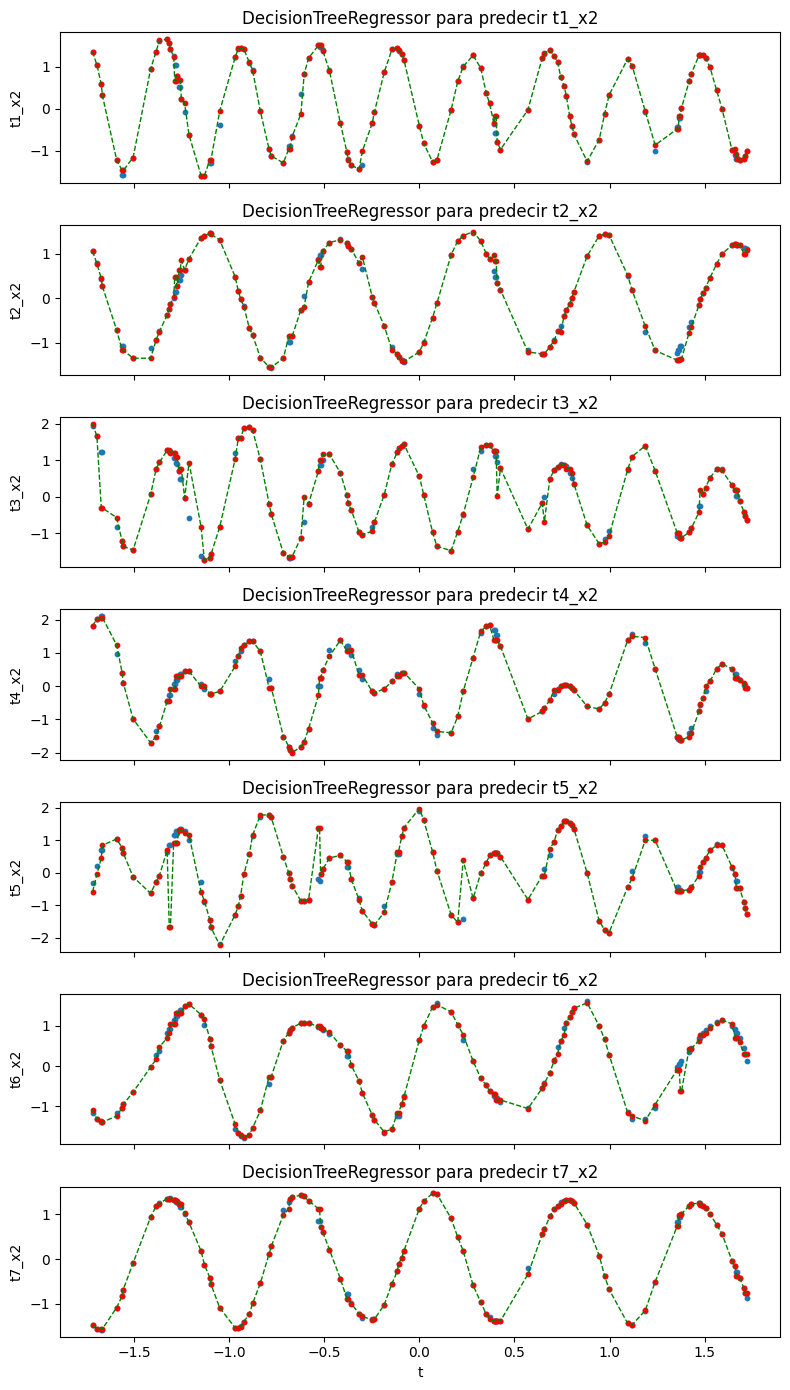

In [12]:
regression(DecisionTreeRegressor())

El modelo DecisionTreeRegressor demuestra un rendimiento excepcional, con errores (MAE, MSE, RMSE) cercanos a cero y coeficientes de determinación (R^2) muy cercanos a 1 para todas las variables de salida (t1_x2 a t7_x2). Esto sugiere una capacidad efectiva para modelar relaciones complejas entre las variables de entrada (t y t_i_x1) y las variables de salida.

### Ahora, apliquemos clasificación

Siguiendo con los modelos de Machine Learning a aplicar, ahora se aplicarán algoritmos de clasificación, estos algoritmos son:
 - ``LogisticRegression``: es un algoritmo de regresión logística utilizado para problemas de clasificación binaria. Modela la probabilidad de pertenencia a una clase y es efectivo en conjuntos de datos linealmente separables.
 - ``KNeighborsClassifier``: implementa k vecinos más cercanos para clasificación. Asigna una etiqueta a un punto basándose en las etiquetas de sus vecinos más cercanos en el espacio de características.
 - ``RandomForestClassifier``: un clasificador basado en ensambles de árboles de decisión. Combina múltiples modelos para mejorar la precisión y generalización del modelo.
 - ``SVC (Support Vector Classification)``: un clasificador de máquinas de soporte vectorial que encuentra el hiperplano óptimo para separar clases en un espacio de características de alta dimensión.
 - ``DecisionTreeClassifier``: utiliza un árbol de decisión para realizar decisiones de clasificación. Divide el espacio de características en regiones, asignando etiquetas a través de condiciones en nodos del árbol.

Junto a sus respectivas métricas, las cuales son:
 - ``accuracy_score``: mide la precisión del modelo al calcular la proporción de predicciones correctas sobre el total de predicciones.

 - ``classification_report``: genera un informe de clasificación que incluye precision, recall, f1-score y support para cada clase en un problema de clasificación.

 - ``confusion_matrix``: calcula la matriz de confusión que muestra el número de verdaderos positivos, verdaderos negativos, falsos positivos y falsos negativos.

 - ``ConfusionMatrixDisplay``: ofrece visualización gráfica de la matriz de confusión para facilitar la interpretación del rendimiento del modelo.

In [13]:
# Algoritmos
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# Métricas
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix, ConfusionMatrixDisplay

A diferencia de las regresiones, para este caso se debió realizar una alteración especial para el dataset donde se va a clasificar con base a qué par de datos pertenece, es decir, a qué modo de oscilación son los datos y que sepa predecir con base en las posiciones que se obtienen de ambos masas. Para ello se generó un nuevo dataset el cual solo tiene cuatro columnas, donde la primera es el tiempo el cual se copió siete veces ya que es el mismo tiempo para todos, la segunda y tercera poseen estas posiciones y la cuarta indica a qué par de columnas corresponde.

In [14]:
# Se crea un nuevo DataFrame vacío llamado df_special
df_special = pd.DataFrame()

# Se agrega una columna 't' a df_special que contiene la concatenación de la columna 't' de df,
# replicada 7 veces utilizando la función np.tile
df_special['t'] = np.tile(pd.concat([df['t']], ignore_index=True), 7)

# Se agrega una columna 'x1' a df_special que contiene la concatenación de las columnas
# 't1_x1', 't2_x1', ..., 't7_x1' de df
df_special['x1'] = pd.concat([df['t1_x1'], df['t2_x1'], df['t3_x1'], df['t4_x1'], df['t5_x1'], df['t6_x1'], df['t7_x1']], ignore_index=True)

# Se agrega una columna 'x2' a df_special que contiene la concatenación de las columnas
# 't1_x2', 't2_x2', ..., 't7_x2' de df
df_special['x2'] = pd.concat([df['t1_x2'], df['t2_x2'], df['t3_x2'], df['t4_x2'], df['t5_x2'], df['t6_x2'], df['t7_x2']], ignore_index=True)

# Se agrega una columna 'x_number' a df_special que repite los números del 1 al 7 según la longitud de df (la cantidad de filas en df)
df_special['x_number'] = np.repeat(np.arange(1, 8), len(df))

# Muestra el DataFrame resultante
df_special

,t,x1,x2,x_number
0,0.000000,-0.194338,0.179767,1
1,0.016667,-0.191922,0.177438,1
2,0.033334,-0.191929,0.177424,1
3,0.050001,-0.188284,0.173918,1
4,0.066668,-0.188301,0.173866,1
...,...,...,...,...
4202,9.933532,-0.221313,0.078049,7
4203,9.950199,-0.227353,0.071883,7
4204,9.966866,-0.227350,0.071912,7
4205,9.983533,-0.232583,0.066028,7


Luego, continuamos con la creación de una función llamada `classifier` la cual, al igual que con la regresión, nos ayudará a aplicar los algoritmos de clasificación para cada conjunto de datos.

In [15]:
# Librerías específicas necesarias para el gráfico
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

# Definición de la función classifier que toma un modelo algoritmo como parámetro
def classifier(algoritmo, graph):
    # Divide los datos en conjuntos de entrenamiento y prueba
    X_train, X_test, y_train, y_test = train_test_split(
        df_special.drop(["t","x_number"], axis=1) if graph == True else df_special.drop(["x_number"], axis=1),  # Características
        df_special["x_number"],  # Etiquetas (x_number)
        test_size=0.2,  # Proporción de datos de prueba
        random_state=42  # Semilla aleatoria para reproducibilidad
    )

    # Crea un clasificador con el algoritmo proporcionado
    clf = algoritmo

    # Entrena el clasificador con los datos de entrenamiento
    clf.fit(X_train, y_train)

    # Realiza predicciones en el conjunto de prueba
    y_pred = clf.predict(X_test)

    # Imprime el informe de clasificación
    print(classification_report(y_test, y_pred))

    # Calcula la matriz de confusión
    cm = confusion_matrix(y_test, y_pred)

    # Muestra la matriz de confusión en un gráfico
    cm_plot = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['1', '2', '3', '4', '5', '6', '7']
    )
    cm_plot.plot()
    plt.show()

    pinturillo(algoritmo) if graph == True else None

def pinturillo(algoritmo):
    X_train, X_test, y_train, y = train_test_split(
        df_special.drop(["t","x_number"], axis=1),  # Características (sin x_number)
        df_special["x_number"],  # Etiquetas (x_number)
        test_size=0.2,  # Proporción de datos de prueba
        random_state=42  # Semilla aleatoria para reproducibilidad
    )

    # Normaliza los datos
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X = scaler.transform(X_test)

    # Crea y entrena el modelo
    clf = algoritmo
    clf.fit(X_train_scaled, y_train)

    h = .02  # step size in the mesh
    
    # Create color maps with 7 colors
    cmap_light = ListedColormap(['#FFAAAA', '#ffcc99', '#ffffb3', '#b3ffff', '#c2f0c2', '#ff99ff', '#99ccff'])
    cmap_bold = ListedColormap(['#FF0000', '#ff9933', '#FFFF00', '#00ffff', '#00FF00', '#990099', '#3333ff'])

    # Plot the decision boundary.
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                        np.arange(y_min, y_max, h))

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])

    # Put the result into a color plot
    Z = Z.reshape(xx.shape[0], xx.shape[1])
    plt.figure()
    plt.pcolormesh(xx, yy, Z, cmap=cmap_light)

    # Plot also the training points
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold,
                edgecolor='k', s=20)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

    # Define legend for 7 classes
    patch0 = mpatches.Patch(color='#FF0000', label='1')
    patch1 = mpatches.Patch(color='#ff9933', label='2')
    patch2 = mpatches.Patch(color='#FFFF00', label='3')
    patch3 = mpatches.Patch(color='#00ffff', label='4')
    patch4 = mpatches.Patch(color='#00FF00', label='5')
    patch5 = mpatches.Patch(color='#990099', label='6')
    patch6 = mpatches.Patch(color='#3333ff', label='7')
    plt.legend(handles=[patch0, patch1, patch2, patch3, patch4, patch5, patch6])

    plt.title("Clasificador de 7 clases ('%s')" % algoritmo.__class__.__name__)

    plt.show()

#### `LogisticRegression`

              precision    recall  f1-score   support

           1       0.60      0.10      0.18       145
           2       0.50      1.00      0.66       120
           3       0.25      0.33      0.28       123
           4       0.99      0.93      0.96       115
           5       0.93      0.99      0.96       108
           6       0.63      0.69      0.66       113
           7       0.22      0.12      0.15       118

    accuracy                           0.57       842
   macro avg       0.59      0.60      0.55       842
weighted avg       0.58      0.57      0.53       842



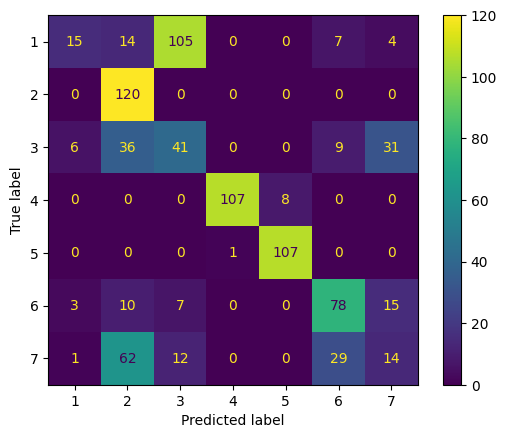

In [16]:
classifier(LogisticRegression(random_state=42),False)

Presenta un rendimiento moderado con un accuracy del 57%. La precision varía, siendo más alta para las clases 4 y 5, y más baja para las clases 1 y 7. El recall es bajo para las clases 1 y 7, mientras que es alto para las clases 2 y 5. En general, las métricas sugieren un desempeño limitado para este modelo.

A continuación, una forma más gráfica utilizando solo dos características.

              precision    recall  f1-score   support

           1       0.62      0.03      0.07       145
           2       0.44      1.00      0.61       120
           3       0.26      0.37      0.30       123
           4       0.99      0.94      0.96       115
           5       0.94      0.99      0.96       108
           6       0.73      0.68      0.70       113
           7       0.25      0.13      0.17       118

    accuracy                           0.57       842
   macro avg       0.60      0.59      0.54       842
weighted avg       0.60      0.57      0.52       842



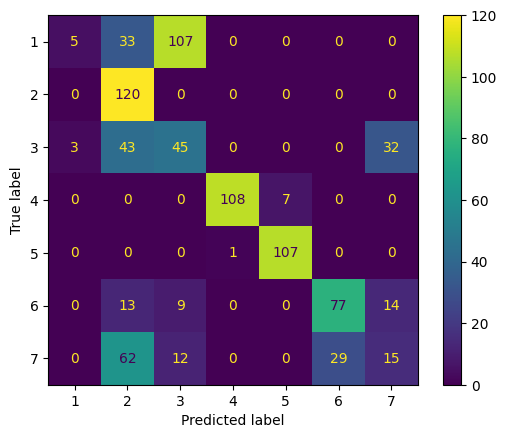

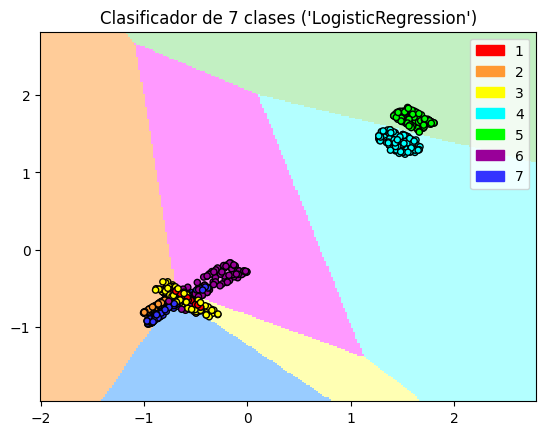

In [17]:
classifier(LogisticRegression(random_state=42),True)

#### `KNeighborsClassifier`

              precision    recall  f1-score   support

           1       0.83      0.79      0.81       145
           2       0.86      0.84      0.85       120
           3       0.72      0.73      0.73       123
           4       1.00      1.00      1.00       115
           5       1.00      1.00      1.00       108
           6       0.94      0.92      0.93       113
           7       0.83      0.89      0.86       118

    accuracy                           0.88       842
   macro avg       0.88      0.88      0.88       842
weighted avg       0.88      0.88      0.88       842



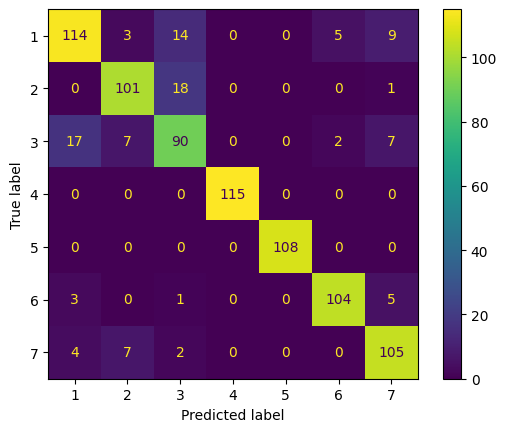

In [18]:
classifier(KNeighborsClassifier(),False)

Obtiene un rendimiento sólido con un accuracy del 88%. Presenta precision, recall y f1-score elevados en todas las clases, indicando una buena capacidad para clasificar las etiquetas.

A continuación, una forma más gráfica utilizando solo dos características.

              precision    recall  f1-score   support

           1       0.92      0.97      0.94       145
           2       0.93      1.00      0.96       120
           3       0.87      0.79      0.83       123
           4       1.00      1.00      1.00       115
           5       1.00      1.00      1.00       108
           6       0.85      0.71      0.77       113
           7       0.86      0.97      0.91       118

    accuracy                           0.92       842
   macro avg       0.92      0.92      0.92       842
weighted avg       0.92      0.92      0.92       842



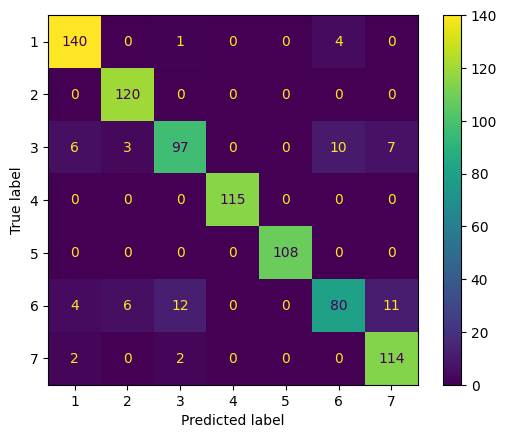

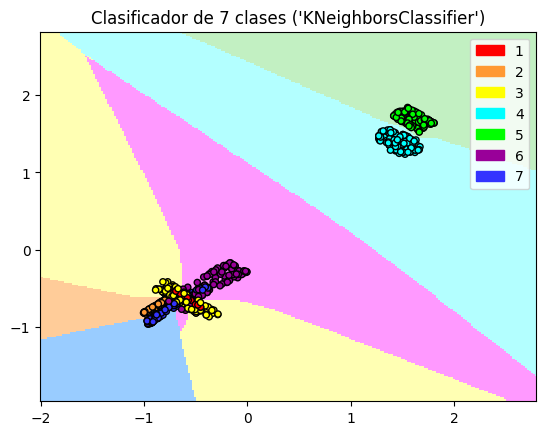

In [19]:
classifier(KNeighborsClassifier(),True)

#### `RandomForestClassifier`

              precision    recall  f1-score   support

           1       0.95      1.00      0.98       145
           2       1.00      1.00      1.00       120
           3       0.98      0.93      0.95       123
           4       1.00      1.00      1.00       115
           5       1.00      1.00      1.00       108
           6       0.98      0.96      0.97       113
           7       0.97      0.98      0.97       118

    accuracy                           0.98       842
   macro avg       0.98      0.98      0.98       842
weighted avg       0.98      0.98      0.98       842



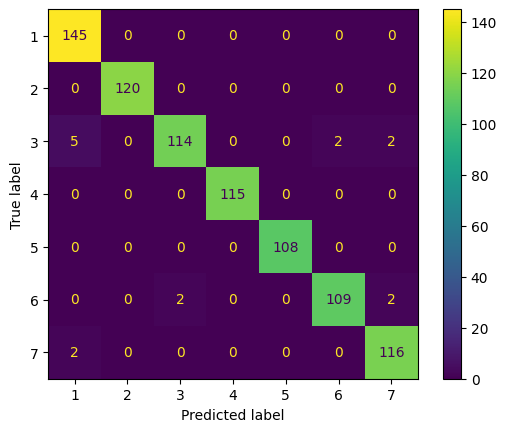

In [20]:
classifier(RandomForestClassifier(random_state=42),False)

Muestra un excelente rendimiento con un accuracy del 98%. Altos valores de precision, recall y f1-score en todas las clases indican una capacidad excepcional para clasificar las etiquetas.

A continuación, una forma más gráfica utilizando solo dos características.

              precision    recall  f1-score   support

           1       0.95      0.97      0.96       145
           2       0.98      0.99      0.98       120
           3       0.97      0.91      0.94       123
           4       1.00      1.00      1.00       115
           5       1.00      1.00      1.00       108
           6       0.88      0.88      0.88       113
           7       0.97      0.98      0.97       118

    accuracy                           0.96       842
   macro avg       0.96      0.96      0.96       842
weighted avg       0.96      0.96      0.96       842



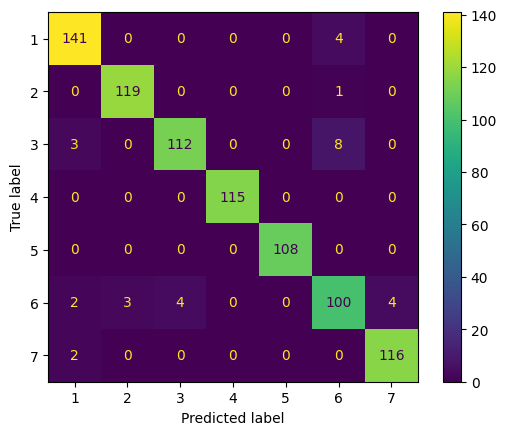

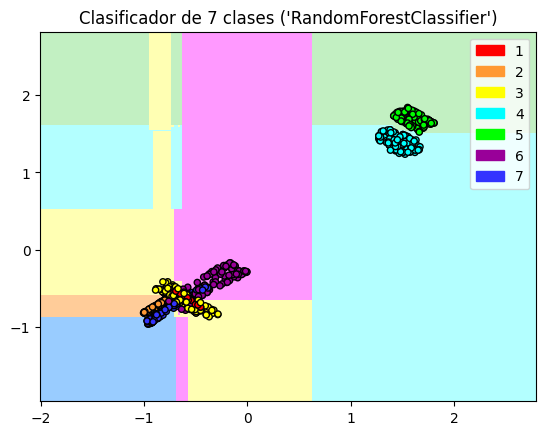

In [21]:
classifier(RandomForestClassifier(random_state=42),True)

#### `SVC`

              precision    recall  f1-score   support

           1       0.00      0.00      0.00       145
           2       0.33      0.36      0.34       120
           3       0.00      0.00      0.00       123
           4       0.48      0.52      0.50       115
           5       0.44      0.41      0.43       108
           6       0.27      0.68      0.39       113
           7       0.20      0.35      0.25       118

    accuracy                           0.31       842
   macro avg       0.25      0.33      0.27       842
weighted avg       0.23      0.31      0.26       842



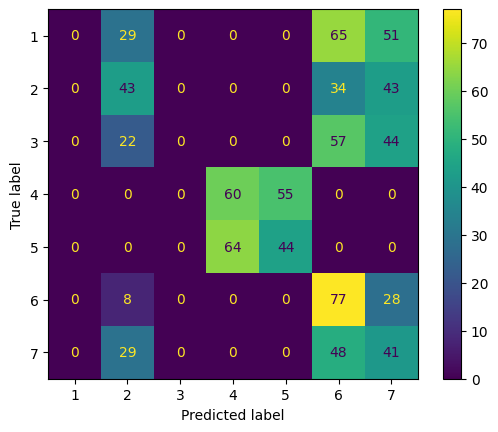

In [22]:
classifier(SVC(kernel='rbf'),False)

Tiene un rendimiento limitado con un accuracy del 31%. La precision, recall y f1-score son bajas para varias clases, sugiriendo dificultades en la clasificación.

A continuación, una forma más gráfica utilizando solo dos características.

              precision    recall  f1-score   support

           1       0.59      0.93      0.72       145
           2       0.80      0.84      0.82       120
           3       0.53      0.54      0.54       123
           4       1.00      1.00      1.00       115
           5       1.00      1.00      1.00       108
           6       0.80      0.58      0.68       113
           7       1.00      0.47      0.64       118

    accuracy                           0.77       842
   macro avg       0.82      0.77      0.77       842
weighted avg       0.81      0.77      0.77       842



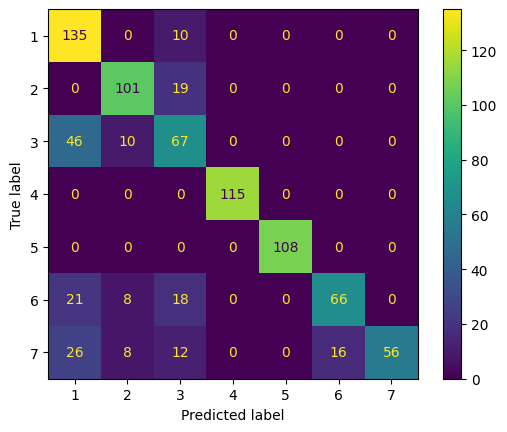

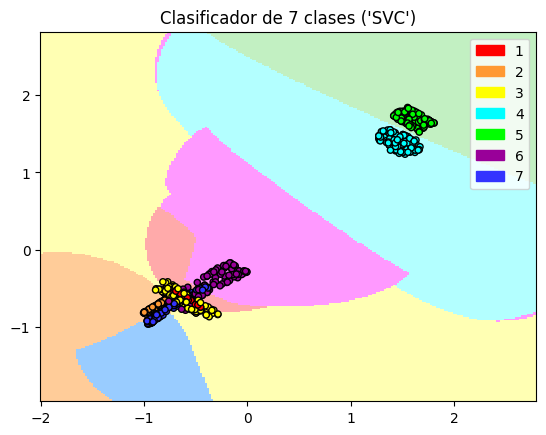

In [23]:
classifier(SVC(kernel='rbf'),True)

#### `DecisionTreeClassifier`

              precision    recall  f1-score   support

           1       0.96      0.93      0.95       145
           2       0.99      0.99      0.99       120
           3       0.93      0.91      0.92       123
           4       1.00      0.98      0.99       115
           5       0.98      1.00      0.99       108
           6       0.86      0.89      0.88       113
           7       0.94      0.97      0.95       118

    accuracy                           0.95       842
   macro avg       0.95      0.95      0.95       842
weighted avg       0.95      0.95      0.95       842



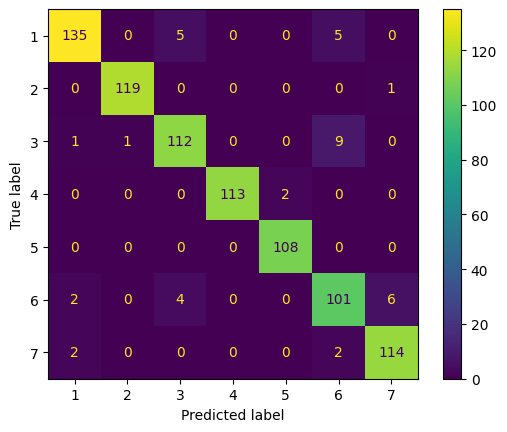

In [24]:
classifier(DecisionTreeClassifier(random_state=42),False)

Exhibe un rendimiento sólido con un accuracy del 95%. Muestra precision, recall y f1-score elevados en todas las clases, indicando una buena capacidad para clasificar las etiquetas.

A continuación, una forma más gráfica utilizando solo dos características.

              precision    recall  f1-score   support

           1       0.97      0.92      0.95       145
           2       0.97      0.97      0.97       120
           3       0.92      0.93      0.93       123
           4       1.00      0.98      0.99       115
           5       0.98      1.00      0.99       108
           6       0.86      0.89      0.88       113
           7       0.95      0.96      0.95       118

    accuracy                           0.95       842
   macro avg       0.95      0.95      0.95       842
weighted avg       0.95      0.95      0.95       842



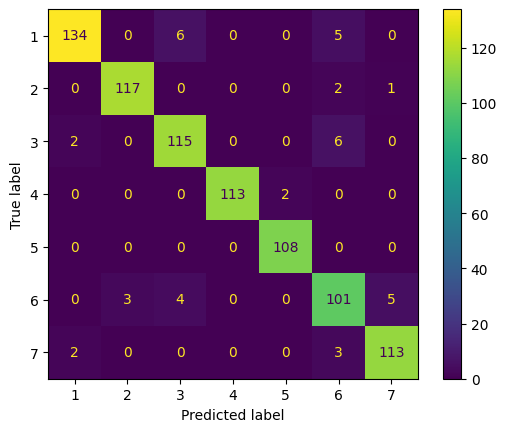

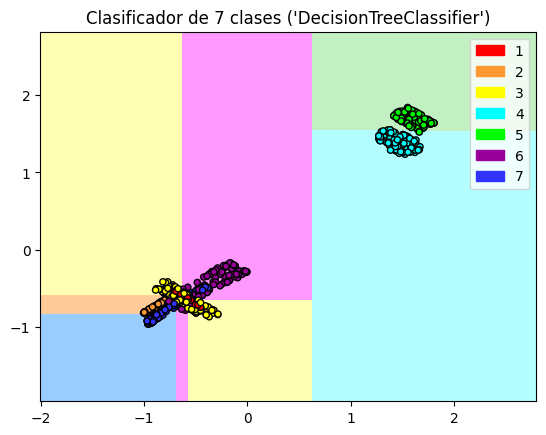

In [25]:
classifier(DecisionTreeClassifier(random_state=42),True)

### Por último, apliquemos agrupación por clusters

Para hacer Machine Learning con clusters estando ahora dentro del campo del lenguaje no supervisado, se usaron las siguientes librerías:
 - `KMeans`: es un algoritmo de clustering que agrupa datos en k clusters basándose en la distancia euclidiana. Utiliza la minimización de la varianza intra-cluster para asignar puntos a clusters, siendo una técnica popular para segmentar datos.
 - `DBSCAN`: es un algoritmo de clustering que identifica clusters basándose en la densidad de los puntos. Puede encontrar clusters de formas arbitrarias y es eficaz para identificar puntos de ruido en conjuntos de datos.

Junto, obviamente, a la métrica utilizada para la evaluación de los clusters:
 - `silhouette_score`: es una métrica de evaluación para algoritmos de clustering, como KMeans. Mide qué tan bien están separados los clusters, proporcionando un valor entre -1 y 1. Un valor más alto indica una mejor separación y cohesión de los clusters, siendo útil para determinar la calidad de la agrupación.

In [26]:
# Algoritmos
from sklearn.cluster import KMeans, DBSCAN

# Métricas
from sklearn.metrics import silhouette_score

# Anexo
from mpl_toolkits.mplot3d import Axes3D # Para visualización 3D

Para este caso, nuevamente realizamos una estandarización de los datos para así obtener mejores resultados y nos aprovecharemos del DataFrame `df_special` que fue creado previamente ya que posee a perfección los datos que vamos a requerir para hacer clustering.

In [27]:
# Inicializar el scaler
scaler = StandardScaler()

# Estandarizar todo el DataFrame
df_cluster = pd.DataFrame(scaler.fit_transform(df_special), columns=df_special.columns)

# Seleccionar las tres primeras columnas
X = df_cluster.iloc[:, :3]

#### `kMeans`

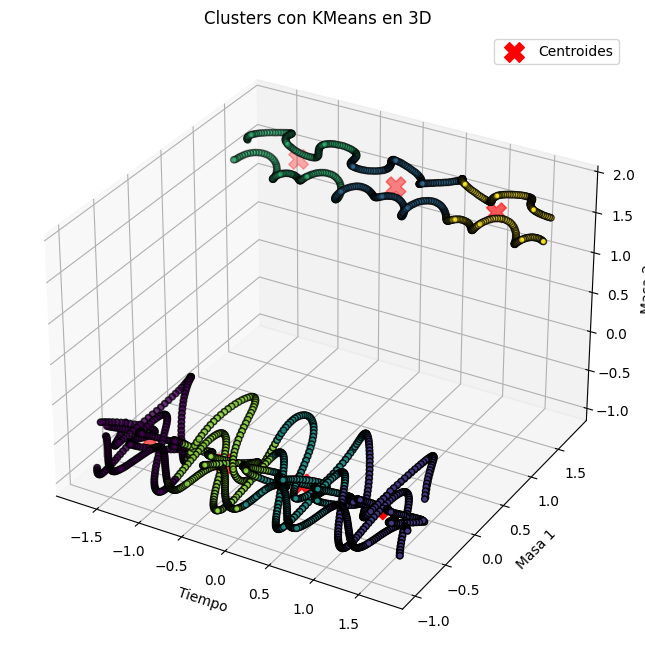

In [28]:
# Crear el modelo KMeans
kmeans = KMeans(n_clusters=7, random_state=42)

# Entrenar el modelo
kmeans.fit(X)

# Asignar cada punto a un cluster
df_cluster['Cluster'] = kmeans.labels_

# Reiniciar el índice del DataFrame df
df_cluster.reset_index(drop=True, inplace=True)

# Visualizar los clusters en 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X.iloc[:, 0], X.iloc[:, 1], X.iloc[:, 2], c=df_cluster['Cluster'], cmap='viridis', edgecolor='k')
ax.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], kmeans.cluster_centers_[:, 2], c='red', marker='X', s=200, label='Centroides')

ax.set_title('Clusters con KMeans en 3D')
ax.set_xlabel('Tiempo')
ax.set_ylabel('Masa 1')
ax.set_zlabel('Masa 2')
ax.legend()

plt.show()

In [29]:
df_cluster

,t,x1,x2,x_number,Cluster
0,-1.729171,-0.742531,-0.506951,-1.5,0
1,-1.723407,-0.733969,-0.513789,-1.5,0
2,-1.717643,-0.733991,-0.513831,-1.5,0
3,-1.711880,-0.721076,-0.524126,-1.5,0
4,-1.706116,-0.721136,-0.524278,-1.5,0
...,...,...,...,...,...
4202,1.706116,-0.838120,-0.805635,1.5,1
4203,1.711880,-0.859525,-0.823741,1.5,1
4204,1.717643,-0.859514,-0.823653,1.5,1
4205,1.723407,-0.878057,-0.840931,1.5,1


In [30]:
print("Silhouette score:",silhouette_score(X,kmeans.labels_))
print("Inertia:",kmeans.inertia_)
print("Score:",kmeans.score(X))

Silhouette score: 0.44428567725489027
Inertia: 594.6100589217278
Score: -594.6100589217278


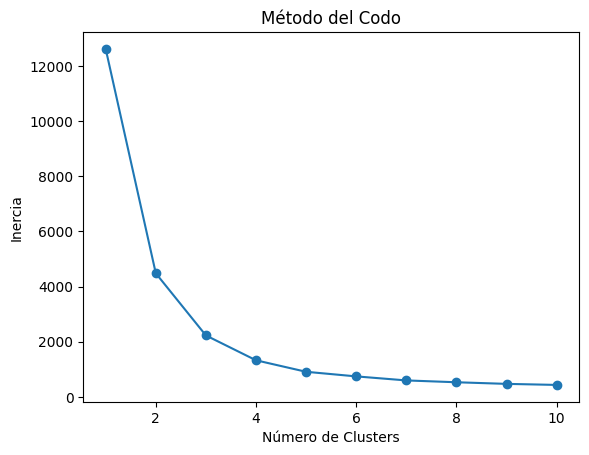

In [31]:
# Lista para almacenar la inercia
inertia = []

# Probar diferentes valores de k
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

# Graficar el método del codo
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Método del Codo')
plt.xlabel('Número de Clusters')
plt.ylabel('Inercia')
plt.show()

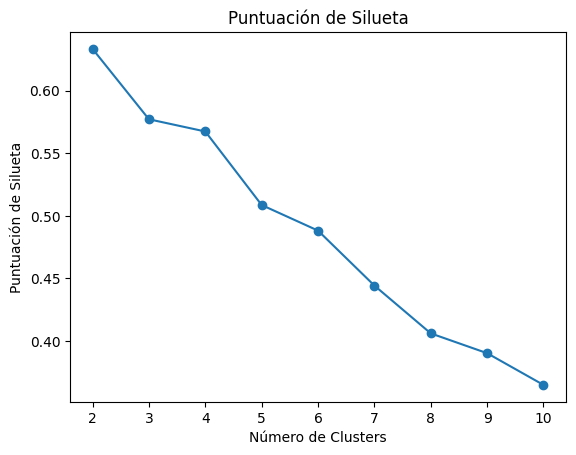

In [32]:
# Lista para almacenar la puntuación de silueta
silhouette_scores = []

# Probar diferentes valores de k
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    silhouette_scores.append(silhouette_score(X, kmeans.labels_))

# Graficar la puntuación de silueta
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title('Puntuación de Silueta')
plt.xlabel('Número de Clusters')
plt.ylabel('Puntuación de Silueta')
plt.show()

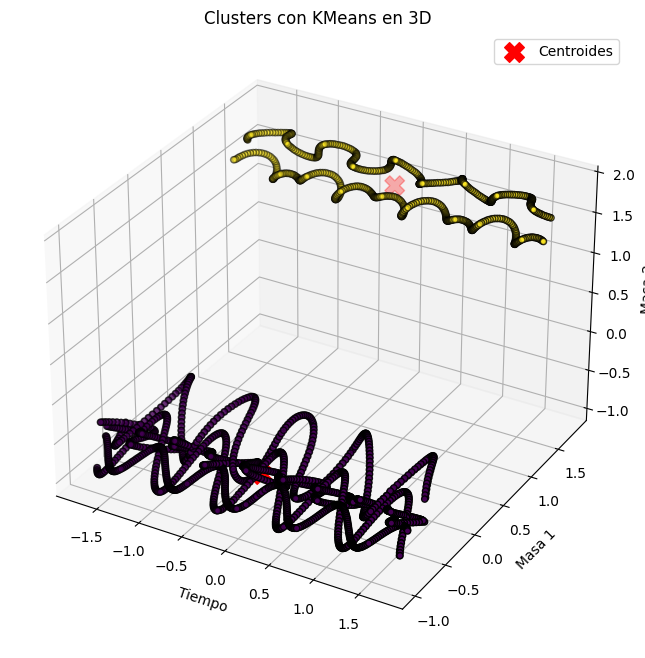

In [33]:
# Crear el modelo KMeans
kmeans = KMeans(n_clusters=2, random_state=42)

# Entrenar el modelo
kmeans.fit(X)

# Asignar cada punto a un cluster
df_special['Cluster'] = kmeans.labels_

# Reiniciar el índice del DataFrame df
df_special.reset_index(drop=True, inplace=True)

# Visualizar los clusters en 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X.iloc[:, 0], X.iloc[:, 1], X.iloc[:, 2], c=df_special['Cluster'], cmap='viridis', edgecolor='k')
ax.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], kmeans.cluster_centers_[:, 2], c='red', marker='X', s=200, label='Centroides')

ax.set_title('Clusters con KMeans en 3D')
ax.set_xlabel('Tiempo')
ax.set_ylabel('Masa 1')
ax.set_zlabel('Masa 2')
ax.legend()

plt.show()

In [34]:
df_cluster

,t,x1,x2,x_number,Cluster
0,-1.729171,-0.742531,-0.506951,-1.5,0
1,-1.723407,-0.733969,-0.513789,-1.5,0
2,-1.717643,-0.733991,-0.513831,-1.5,0
3,-1.711880,-0.721076,-0.524126,-1.5,0
4,-1.706116,-0.721136,-0.524278,-1.5,0
...,...,...,...,...,...
4202,1.706116,-0.838120,-0.805635,1.5,1
4203,1.711880,-0.859525,-0.823741,1.5,1
4204,1.717643,-0.859514,-0.823653,1.5,1
4205,1.723407,-0.878057,-0.840931,1.5,1


In [35]:
print("Silhouette score:",silhouette_score(X,kmeans.labels_))
print("Inertia:",kmeans.inertia_)
print("Score:",kmeans.score(X))

Silhouette score: 0.6334581043132106
Inertia: 4481.273096705246
Score: -4481.273096705246


#### `DBSCAN`

In [36]:
# Inicia con valores nulos
best_eps = None
best_min_samples = None
best_num_clusters = 0
best_silhouette_score = -1

# Itera entre diferentes valores para eps y min_samples y encuentra el de la mejor métrica silhouette_score
for eps in np.arange(0.1, 1.0, 0.1):
    for min_samples in range(1, 10):
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X)

        # Ignora clusters ruidosos (-1)
        num_clusters = len(set(labels)) - (1 if -1 in labels else 0)

        if num_clusters > 1:  # Necesitas al menos dos clusters
            silhouette_avg = silhouette_score(X, labels)
            if silhouette_avg > best_silhouette_score:
                best_silhouette_score = silhouette_avg
                best_eps = eps
                best_min_samples = min_samples
                best_num_clusters = num_clusters

# Imprimir los mejores resultados
print("Mejores parámetros:")
print(f"Eps: {best_eps}")
print(f"Min_samples: {best_min_samples}")
print(f"Número de clusters: {best_num_clusters}")
print(f"Puntuación de silueta: {best_silhouette_score}")

Mejores parámetros:
Eps: 0.2
Min_samples: 1
Número de clusters: 2
Puntuación de silueta: 0.6334581043132106


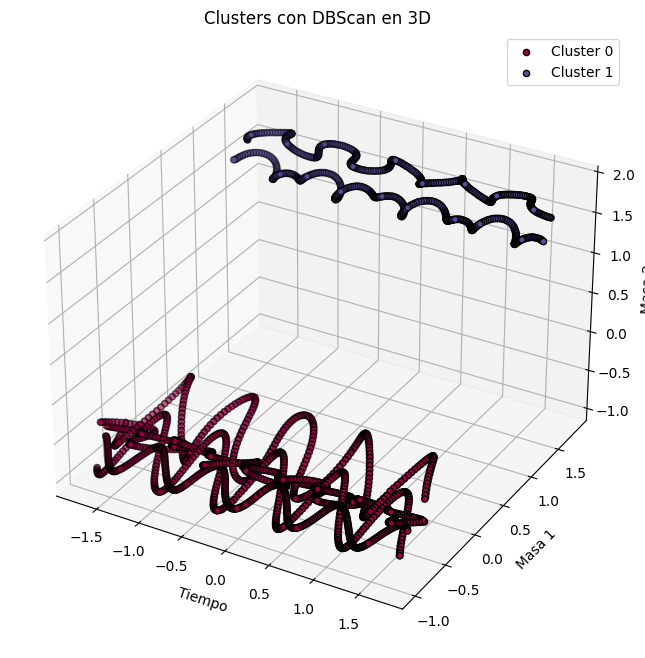

In [37]:
# Seleccionar las columnas de interés
X = df_cluster[['t', 'x1', 'x2']]

# Configurar el modelo DBSCAN
dbscan = DBSCAN(eps=best_eps, min_samples=best_min_samples)

# Entrenar el modelo y asignar etiquetas
df_cluster['Cluster'] = dbscan.fit_predict(X)

# Visualizar los clusters en 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

unique_labels = set(df_cluster['Cluster'])
colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels)))

for label, color in zip(unique_labels, colors):
    cluster_mask = (df_cluster['Cluster'] == label)
    ax.scatter(df_cluster.loc[cluster_mask, 't'], df_cluster.loc[cluster_mask, 'x1'], df_cluster.loc[cluster_mask, 'x2'], c=[color], edgecolor='k', label=f'Cluster {label}')

ax.set_title('Clusters con DBScan en 3D')
ax.set_xlabel('Tiempo')
ax.set_ylabel('Masa 1')
ax.set_zlabel('Masa 2')
ax.legend()

plt.show()

In [38]:
df_cluster

,t,x1,x2,x_number,Cluster
0,-1.729171,-0.742531,-0.506951,-1.5,0
1,-1.723407,-0.733969,-0.513789,-1.5,0
2,-1.717643,-0.733991,-0.513831,-1.5,0
3,-1.711880,-0.721076,-0.524126,-1.5,0
4,-1.706116,-0.721136,-0.524278,-1.5,0
...,...,...,...,...,...
4202,1.706116,-0.838120,-0.805635,1.5,0
4203,1.711880,-0.859525,-0.823741,1.5,0
4204,1.717643,-0.859514,-0.823653,1.5,0
4205,1.723407,-0.878057,-0.840931,1.5,0
